# QKD·BB84 강의 노트북
## 양자 키 분배와 BB84 프로토콜 (Quantum Key Distribution & BB84 Protocol)

---

이 노트북은 **물리학 비전공자도 이해할 수 있도록** 양자 키 분배(QKD)를 쉽게 풀어 쓴 강의 자료입니다.
핵심 아이디어는 하나입니다. **"열어 보면 반드시 구겨지는 특수 편지봉투로 비밀 열쇠를 주고받으면,
누가 중간에서 몰래 뜯어봤는지 100% 알 수 있다"** — 이런 물리 법칙 기반의 도청 탐지를
수식 대신 코드와 실측으로 확인합니다.

QKD의 물리적 원리 → BB84 프로토콜 이론 → 도청자(Eve)를 포함한 시뮬레이션 →
QBER(오류율)로 도청 잡아내기 → 실무 적용성과 PQC vs QKD 보완 관계 순서로 진행하며,
**"엿보면 반드시 들킨다"는 성질이 실제로 어떻게 동작하는지** 숫자로 확인합니다.

> **안내**: 이 노트북은 통합본 `양자내성암호_입문자용_v3.ipynb`에서 해당 주제(QKD·BB84)를
> 분리·정리한 강의 자료입니다. 코드 셀과 출력은 원본 그대로이며,
> 재실행하려면 **0장(Setup) 셀을 먼저 실행**해야 합니다.

### 학습 목표
1. QKD가 PQC(수학 문제 기반 소프트웨어 암호)와 어떻게 다른 방식으로 보안을 지키는지 감을 잡는다.
2. BB84 프로토콜의 네 단계(보내기 → 재기 → 맞춰 보기 → 오류율 검사)를 이해한다.
3. 도청자 Eve가 중간에서 가로채 엿보는 공격을 코드로 직접 시뮬레이션한다.
4. 오류율(QBER)이 기준선(약 0.11)을 넘으면 "도청 있음"으로 판정하고 키를 버리는 절차를 확인한다.
5. QKD의 거리·비용 한계를 알고, PQC와 역할을 나눠 함께 쓰는 이유를 설명할 수 있다.

> **선행 지식**: 어려운 물리학은 필요 없습니다. 양자역학에서는 딱 두 가지만 기억하면 됩니다 —
> "① 양자 상태는 들여다보는(측정하는) 순간 바뀐다, ② 모르는 양자 상태는 복사할 수 없다."
> 나머지는 기초 확률(동전 던지기 수준)과 파이썬 코드를 대략 읽을 수 있으면 충분합니다.


## 0. 준비 (Setup)

아래 셀은 통합본 전체가 공유하는 **공통 도구 상자(하니스, harness)** 입니다.
매번 같은 실험 결과가 나오도록 난수(무작위 수)의 시작점을 고정한 `RNG`(시드 20260722),
그래프에서 한글이 깨지지 않게 하는 폰트 설정,
해시·크기·시간 측정 헬퍼, 그리고 측정값을 모아 두는 `METRICS` 저장소를 정의합니다.
이 노트북에서는 `RNG`, `matplotlib`, `log_metric`만 사용하지만, 셀 전체를 먼저 실행해야 합니다.

> 그래프(matplotlib) 안의 텍스트는 폰트 호환을 위해 영어로 표기합니다.


In [1]:
import time, hashlib, secrets, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import gcd, log2, floor, pi, sqrt

RNG = np.random.default_rng(20260722)   # 재현성 시드
plt.rcParams['figure.dpi'] = 110

# --- 한글 폰트 자동 설정 (그래프의 한글이 □□□로 깨지지 않게) ---
import matplotlib.font_manager as fm

def set_korean_font():
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
                  'Noto Sans CJK KR', 'Noto Sans KR', 'NanumBarunGothic']
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            plt.rcParams['font.family'] = name
            plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지
            return name
    # 못 찾으면 리눅스/Colab에서 나눔폰트 설치 시도
    try:
        import subprocess, sys
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
                       capture_output=True)
        for path in fm.findSystemFonts():
            if 'Nanum' in path:
                fm.fontManager.addfont(path)
        for name in candidates:
            if name in {f.name for f in fm.fontManager.ttflist}:
                plt.rcParams['font.family'] = name
                plt.rcParams['axes.unicode_minus'] = False
                return name
    except Exception:
        pass
    plt.rcParams['axes.unicode_minus'] = False
    print('⚠️ 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있어요. '
          'NanumGothic 등 한글 폰트를 설치한 뒤 다시 실행하세요.')
    return None

_font = set_korean_font()

# --- 해시 헬퍼 (해시 기반 서명·KEM 공유비밀에 사용) ---
def H(b: bytes) -> bytes:
    return hashlib.sha256(b).digest()
def shake(b: bytes, n: int) -> bytes:
    return hashlib.shake_128(b).digest(n)

# --- 크기 측정: 객체를 바이트로 직렬화해 대략적 전송량(byte)을 잰다 ---
def nbytes(obj) -> int:
    if isinstance(obj, (bytes, bytearray)):
        return len(obj)
    if isinstance(obj, np.ndarray):
        return obj.astype(np.int64).nbytes
    if isinstance(obj, (list, tuple)):
        return sum(nbytes(x) for x in obj)
    if isinstance(obj, str):
        return len(obj.encode())
    if isinstance(obj, int):
        return (obj.bit_length() + 7) // 8
    return sys.getsizeof(obj)

# --- 시간 측정 ---
def timeit(fn, *a, repeat=1, **k):
    t0 = time.perf_counter()
    for _ in range(repeat):
        out = fn(*a, **k)
    dt = (time.perf_counter() - t0) / repeat
    return out, dt

# --- 정량 지표 저장소 (Part IV 종합 비교에서 사용) ---
METRICS = {}
def log_metric(name, **kv):
    METRICS.setdefault(name, {}).update(kv)

print('Harness 준비 완료 · Python', sys.version.split()[0], '· NumPy', np.__version__,
      '· 한글 폰트:', _font)

Harness 준비 완료 · Python 3.13.14 · NumPy 2.4.6 · 한글 폰트: Malgun Gothic


## 1. QKD란 무엇인가 — PQC와 다른 접근

지금까지 살펴본 **PQC(양자내성암호)** 는 "양자컴퓨터도 풀기 어려운 수학 문제"를 자물쇠로 쓰는,
**소프트웨어** 방식의 보안입니다. 반면 **QKD(Quantum Key Distribution, 양자 키 분배)** 는
수학이 아니라 **양자역학이라는 물리 법칙 자체**를 이용해, **하드웨어(광섬유와 광자 장비)** 로
도청을 잡아냅니다.

쉽게 비유하면 이렇습니다 —
- **PQC** = 어디에나 설치할 수 있는 **소프트웨어 자물쇠**. 업데이트만 하면 전 세계 어디서든 쓸 수 있습니다.
- **QKD** = 특정 구간(예: 서울–대전 전용 회선)에 설치하는 **물리적 감시 장치**.
  누가 선을 건드리면 반드시 경보가 울립니다.

접근이 근본적으로 다르기 때문에 두 기술은 **경쟁이 아니라 보완 관계**입니다.
이 장에서는 QKD의 대표 프로토콜인 **BB84**를 도청자(Eve)까지 넣어 실제로 시뮬레이션하고,
도청이 어떻게 들키는지 숫자로 확인합니다.


## 2. BB84 프로토콜 이론

### 2-1. 안전성의 근거 — 두 가지 물리 법칙

QKD의 안전성은 "계산이 오래 걸려서"가 아니라, 다음 두 가지 **물리 법칙**에서 나옵니다.

1. **관측하면 바뀐다**: 빛 알갱이(광자)에 실린 정보는 누군가 들여다보는(측정하는) 순간 흐트러집니다.
2. **복제 불가 정리(no-cloning theorem)**: 내용을 모르는 양자 상태는 완벽하게 복사할 수 없습니다.
   즉 도청자가 "원본은 복사해 두고 몰래 보기"를 할 수 없습니다.

따라서 누군가 중간에서 몰래 엿보면 반드시 **흔적(오류)** 이 남습니다.
비유하자면, **열면 반드시 구겨지는 특수 편지봉투**로 열쇠를 주고받는 것과 같습니다 —
봉투가 구겨져 도착하면 "누가 뜯어봤구나"를 바로 알 수 있습니다.

### 2-2. BB84 절차

BB84(제안자 Bennett과 Brassard의 이름, 1984년 발표)는 다음 네 단계로 진행됩니다.
보내는 사람을 Alice, 받는 사람을 Bob이라고 부릅니다(암호학의 관례적 등장인물입니다).

- **(a) 전송**: Alice가 무작위 비트(0/1)를 만들고, 광자를 싣는 '방향 틀'인 **기저** 두 가지
  (직선 $+$, 대각 $\times$) 중 하나를 동전 던지듯 무작위로 골라 광자에 실어 보냅니다.
  기저는 "글자를 가로로 쓸지 세로로 쓸지" 정도의 방향 약속이라고 생각하면 됩니다.
- **(b) 측정**: Bob도 각 광자를 자기 마음대로 고른 무작위 기저로 측정합니다.
  Bob이 Alice와 **같은 기저**를 골랐으면 비트가 정확히 읽히고, **다른 기저**면 결과가 반반 무작위가 됩니다.
- **(c) 기저 대조(sifting, 거르기)**: 전송이 끝난 뒤, 둘은 공개 통화로 **"몇 번째에 어떤 기저를 썼는지"만**
  서로 알려 줍니다(비트 값 자체는 말하지 않습니다). 기저가 **우연히 일치한 위치의 비트만** 남기는데,
  기저 선택이 동전 던지기이므로 평균적으로 **절반**이 살아남습니다.
  도청이 없었다면 남은 비트들은 완벽히 일치합니다.
- **(d) 오류율 검사**: 걸러진 키의 일부를 공개적으로 맞춰 보고, 틀린 비율 —
  **QBER(Quantum Bit Error Rate, 양자 비트 오류율)** — 을 잽니다. 이 숫자가 도청 탐지기입니다.

### 2-3. 도청 모델과 판정 기준

도청자 **Eve**가 중간에서 광자를 가로채 측정한 뒤, 들킬까 봐 비슷한 광자를 다시 만들어 보내는 공격을
**intercept-resend(가로채고 다시 보내기)** 공격이라고 합니다.

문제는 Eve가 Alice의 기저를 모른다는 점입니다. Eve도 동전 던지기로 기저를 고를 수밖에 없으므로
평균 절반은 **틀린 기저**로 측정하게 되고, 틀린 기저로 측정한 광자는 상태가 흐트러진 채 재전송됩니다.
그 결과 걸러진 키에 **이론상 약 25%의 오류**가 생깁니다 — 엿본 흔적이 숫자로 남는 것입니다.

> **판정 기준**: QBER $\approx 0$ 이면 안전, QBER $\approx 0.25$ 이면 도청.
> 실무에서는 장비 자체의 자연 오류 여유를 감안해 **기준선 약 0.11**을 쓰며,
> 이를 넘으면 그 키는 통째로 버립니다(폐기).

이 예측이 실제로 맞는지 아래에서 직접 확인합니다.


## 3. 밑바닥 구현과 검증

아래 셀은 BB84 전 과정을 numpy 배열 연산으로 구현한 `bb84` 함수를 정의합니다.
`eve=True`로 켜면 Eve가 무작위 기저로 가로채 다시 보내는 intercept-resend 공격이 중간에 끼어듭니다.
이어서 광자 6,000개를 "도청 없음"과 "도청 있음" 두 조건으로 보내
걸러진 키 길이와 QBER(오류율)를 비교하고, 기준선 `THRESH = 0.11`로 키를 버릴지 판정합니다.


In [23]:
# ③ 밑바닥 구현 — BB84 (Eve 옵션 포함)
def bb84(n_bits, eve=False, rng=None):
    rng = rng or RNG
    a_bits  = rng.integers(0, 2, n_bits)          # Alice 난수 비트
    a_bases = rng.integers(0, 2, n_bits)          # Alice 기저 (0:+, 1:x)
    b_bases = rng.integers(0, 2, n_bits)          # Bob 측정 기저
    if eve:                                       # 도청: Eve가 무작위 기저로 가로채 재전송
        e_bases = rng.integers(0, 2, n_bits)
        e_meas  = np.where(e_bases == a_bases, a_bits, rng.integers(0, 2, n_bits))
        relay_bits, relay_bases = e_meas, e_bases  # Bob은 Eve가 재전송한 광자를 받음
    else:
        relay_bits, relay_bases = a_bits, a_bases
    b_meas = np.where(b_bases == relay_bases, relay_bits, rng.integers(0, 2, n_bits))
    keep = a_bases == b_bases                      # 기저 대조(sifting)
    a_key, b_key = a_bits[keep], b_meas[keep]
    qber = float(np.mean(a_key != b_key)) if keep.sum() else 0.0
    return dict(sent=n_bits, sifted=int(keep.sum()), qber=qber, a_key=a_key, b_key=b_key)

# ④ 검증 — 도청 없음 vs 도청 있음
r_safe = bb84(6000, eve=False)
r_eve  = bb84(6000, eve=True)
print(f'[도청 없음] 전송 {r_safe["sent"]} → 걸러진 키 {r_safe["sifted"]}, QBER = {r_safe["qber"]:.3f}  → ~0 (안전)')
print(f'[도청 있음] 전송 {r_eve["sent"]} → 걸러진 키 {r_eve["sifted"]}, QBER = {r_eve["qber"]:.3f}  → ~0.25 (도청 탐지!)')
THRESH = 0.11   # 실무 임계값(오차정정 여유 포함); 초과 시 키 폐기
print(f'\n임계값 {THRESH} 기준 →  안전:{"통과" if r_safe["qber"]<THRESH else "폐기"} / 도청:{"통과" if r_eve["qber"]<THRESH else "폐기"}')
log_metric('QKD (BB84)', qber_clean=r_safe['qber'], qber_eve=r_eve['qber'])

[도청 없음] 전송 6000 → 걸러진 키 3011, QBER = 0.000  → ~0 (안전)
[도청 있음] 전송 6000 → 걸러진 키 2985, QBER = 0.269  → ~0.25 (도청 탐지!)

임계값 0.11 기준 →  안전:통과 / 도청:폐기


### 3-1. 결과 해석

실행 결과가 2장의 이론 예측과 정확히 일치합니다.

- **도청 없음**: 광자 6,000개를 보내 걸러진 키 3,011비트를 얻었습니다 —
  약 절반만 남은 이유는, 거르기(sifting) 단계에서 두 사람의 기저가 우연히 일치할 확률이
  동전 던지기처럼 1/2이기 때문입니다. **QBER = 0.000**, 즉 두 사람의 키가 완벽히 일치합니다.
- **도청 있음**: 걸러진 키 2,985비트, **QBER = 0.269**. 이론 예측값 약 0.25(엿본 광자의
  절반이 틀린 기저 → 그중 절반이 오류)에 가까운 오류가 발생해, 도청 흔적이 그대로 드러났습니다.
- **기준선 0.11 판정**: 안전한 키는 **통과**, 도청된 키는 **폐기**로 정확히 갈립니다.

> 핵심은 **도청된 키가 실제로 사용되는 일이 없다**는 점입니다.
> 오류율이 기준선을 넘으면 그 키는 통째로 버리고 새로 만들면 그만입니다.
> 도둑이 열쇠 배달을 엿본 순간 그 열쇠는 폐기되므로, 도둑 손에 들어간 열쇠로 열 수 있는 문이 없습니다.


## 4. 시각화 — 도청 비율에 따른 QBER 변화

Eve가 광자를 전부 가로채지 않고 일부만 살짝 엿보면 어떻게 될까요? 조금만 엿보면 안 들킬까요?
아래 셀은 도청 비율을 0%에서 100%까지 11단계로 늘려 가며(광자 8,000개씩)
오류율(QBER)이 어떻게 올라가는지 재고, 폐기 기준선 0.11과
전량 도청 시의 이론값 0.25를 기준선으로 함께 그립니다.


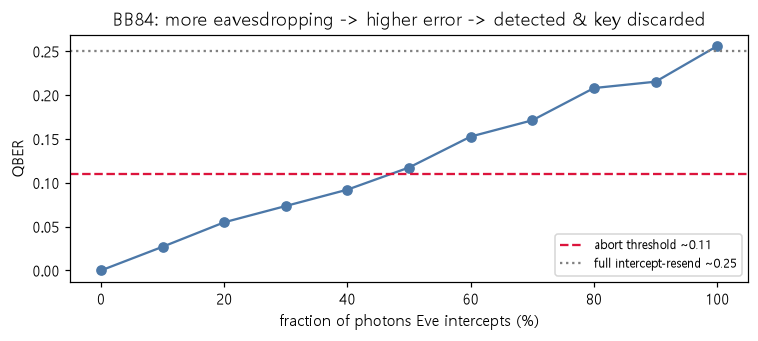

In [24]:
# 도청 비율을 0→100%로 늘리며 QBER 상승 관찰
def bb84_partial_eve(n_bits, eve_frac, rng):
    a_bits=rng.integers(0,2,n_bits); a_bases=rng.integers(0,2,n_bits); b_bases=rng.integers(0,2,n_bits)
    tapped = rng.random(n_bits) < eve_frac
    e_bases=rng.integers(0,2,n_bits)
    e_meas=np.where(e_bases==a_bases, a_bits, rng.integers(0,2,n_bits))
    relay_bits=np.where(tapped, e_meas, a_bits)
    relay_bases=np.where(tapped, e_bases, a_bases)
    b_meas=np.where(b_bases==relay_bases, relay_bits, rng.integers(0,2,n_bits))
    keep=a_bases==b_bases
    return float(np.mean(a_bits[keep]!=b_meas[keep]))

fracs=np.linspace(0,1,11)
qbers=[bb84_partial_eve(8000, f, RNG) for f in fracs]
fig, ax = plt.subplots(figsize=(7,3.2))
ax.plot(fracs*100, qbers, 'o-', color='#4C78A8')
ax.axhline(0.11, color='crimson', ls='--', label='abort threshold ~0.11')
ax.axhline(0.25, color='gray', ls=':', label='full intercept-resend ~0.25')
ax.set_xlabel('fraction of photons Eve intercepts (%)'); ax.set_ylabel('QBER')
ax.set_title('BB84: more eavesdropping -> higher error -> detected & key discarded')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### 4-1. 그래프 해석

- **가로축**은 Eve가 가로채는 광자의 비율(0~100%), **세로축**은 걸러진 키에서 측정된
  오류율(QBER)입니다.
- 도청 0%에서는 QBER가 0에 붙어 있고, 도청 비율이 늘수록 **거의 직선으로 비례해서**
  올라가 100% 도청에서는 약 0.25 수준에 도달합니다(3장의 전량 도청 실측값은 0.269였습니다).
  **엿본 만큼 정확히 비례해서 흔적이 쌓이는** 셈입니다 — 절반만 엿보면 절반만큼의 흔적이 남습니다.
- 빨간 점선 **0.11**(abort threshold, 폐기 기준선)이 판정선입니다. QBER가 이 선을 넘으면
  해당 키는 통째로 폐기됩니다. 그래프에서 보듯 도청 비율이 절반 근처만 되어도 이미 기준선을 훌쩍 넘습니다.

> **핵심**: QKD는 도청을 "막는" 기술이 아니라 **"반드시 들키게 하는"** 기술입니다.
> CCTV가 도둑의 침입 자체를 막지는 못해도 반드시 기록을 남기는 것과 같습니다.
> 따라서 오류율 측정 후 "들켰으면 키를 버리고 다시 만드는" 절차까지 포함해야
> 하나의 완결된 보안 시스템이 됩니다.


## 5. 실무 적용성과 PQC vs QKD 보완 관계

### 5-1. 실무 적용성

- **측정 결과 요약**: 도청이 없으면 QBER $\approx 0$, 가로채기 도청이 있으면
  QBER $\approx 0.25$가 나오며, 기준선을 넘으면 키를 **폐기**하므로 도청된 키는
  절대 사용되지 않습니다. 이 성질은 공격자의 컴퓨터가 아무리 좋아져도 변하지 않는
  물리 법칙이므로, **이론상 무조건적(unconditional) 안전** — 즉 "계산 능력과 무관한 안전"입니다.
- **한계**: 물리 장비이기에 생기는 제약이 있습니다.
  1. **전송 거리** — 광섬유를 지나며 빛이 약해지는 광손실 때문에 보통 **100 km 안팎**으로
     제한됩니다. 더 멀리 보내려면 중간에 '신뢰 노드(trusted node)' — 믿고 맡길 수 있는
     중계 기지국 — 를 두어야 합니다.
  2. **고비용 하드웨어** — 광자를 한 알씩 쏘고 받는 특수 장비와 전용 광케이블 등
     큰 초기 설비 투자(CAPEX)가 필요합니다.
  3. **범용 망 비호환** — 소프트웨어 업데이트만으로는 깔 수 없어서,
     일반 인터넷 전체 구간에 적용하기는 어렵습니다.
- **국내 현황**: KT·SKT·LGU+가 양자암호통신망을 구축·실증하고 있으며,
  통신망의 굵은 줄기(백본)에는 QKD, 각 가정·회사로 이어지는 가입자망에는 PQC를 결합한
  **하이브리드(둘을 겹쳐 쓰기)** 구성으로 나아가고 있습니다.

### 5-2. PQC vs QKD 비교

| 구분 | **PQC (양자내성암호)** | **QKD (양자 키 분배)** |
|---|---|---|
| 구현 | 소프트웨어 (수학 난제) | 물리 하드웨어 (양자역학) |
| 배포 | 기존 시스템에 업데이트, 어디서나 | 전용 장비·광케이블 필요 |
| 거리 | 제약 없음(인터넷 전 구간) | 100km 안팎 제약 |
| 방어 | 계산적 안전(난제) | 물리적 도청 탐지 |
| 역할 | **키 교환·전자서명 전반** | **키 분배** 구간 강화 |

두 기술은 **대체재가 아니라 보완재**입니다. 소프트웨어 자물쇠(PQC)는 어디에나 달 수 있으니
장거리·범용 구간을 맡고, 물리 감시 장치(QKD)는 값비싼 대신 확실하니 핵심 구간을 강화합니다.
실제로 국내 통신사는 PQC+QKD 하이브리드로 이중 보안망을 구성하고 있으며, 이는 다음 노트북에서 다룰
**하이브리드 전환** 개념으로 자연스럽게 이어집니다.

> **정리**: PQC는 넓게, QKD는 깊게 — 두 방식을 겹쳐 쓰면
> 한쪽이 흔들려도 다른 쪽이 버텨 줍니다.


## 연습문제

직접 코드를 고쳐 보면서 감을 잡아 보세요. 어려운 물리 없이, 숫자만 바꿔 보면 됩니다.

1. **표본 크기와 판정 신뢰도**: 3장의 `bb84(6000, ...)` 호출에서 `n_bits`를
   100, 500 등으로 줄여 여러 번 실행해 보세요. 걸러진 키가 짧아지면
   QBER 추정값이 얼마나 들쭉날쭉해지나요? 여론조사 표본이 너무 적으면 결과를 믿기 어렵듯,
   기준선 0.11 판정이 틀릴 수도 있을까요?

2. **Eve가 기저를 안다면**: `bb84` 함수에서
   `e_bases = rng.integers(0, 2, n_bits)`를 `e_bases = a_bases.copy()`로 바꿔
   실행해 보세요(Eve가 Alice의 기저 선택을 미리 다 아는 상황). QBER가 어떻게 되나요?
   이 결과가 "기저를 무작위로 고르는 것"이 BB84 안전성의 핵심인 이유를 어떻게 보여 주나요?

3. **탐지 한계선 찾기**: 4장의 `fracs = np.linspace(0, 1, 11)`을
   `np.linspace(0, 1, 51)`처럼 촘촘하게 바꾸고, QBER가 기준선 0.11을 넘기 시작하는
   도청 비율이 대략 몇 %인지 그래프에서 읽어 보세요.
   이론 예측(QBER $\approx 0.25 \times$ 도청 비율)과 비교하면 어떤가요?

4. **기준선의 트레이드오프**: 3장의 `THRESH = 0.11`을 0.05와 0.20으로 각각
   바꿔 보세요. 기준선을 낮추면/높이면 어떤 종류의 오판이 늘어날까요?
   (화재경보기 민감도에 비유하면 — 너무 민감하면 멀쩡한 키를 자꾸 버리는 헛경보,
   너무 둔감하면 도청된 키를 통과시키는 미탐지) 3번 결과와 연결해 설명해 보세요.


## 요약

- QKD는 수학 문제(PQC)가 아니라 **물리 법칙**("보면 바뀐다", "복사할 수 없다")으로
  도청을 탐지한다 — 열면 반드시 구겨지는 특수 편지봉투로 열쇠를 주고받는 것과 같다.
- BB84는 무작위 기저로 보내기 → 무작위 기저로 재기 → **기저 맞춰 보기(sifting)** →
  오류율(QBER) 검사의 네 단계로 키를 공유하며, 거르기 후 약 절반의 비트가 살아남는다.
- Eve의 가로채기(intercept-resend) 도청은 걸러진 키에 **약 25%의 오류**를 남긴다
  (시뮬레이션 실측: 도청 없음 0.000, 전량 도청 0.269).
- QBER가 **기준선 0.11**을 넘으면 키를 통째로 버리므로, 도청된 키는 절대 사용되지 않는다.
- 도청 비율이 늘수록 QBER는 거의 비례해서 올라간다 — **엿본 만큼 흔적이 남는다**.
- QKD는 거리(약 100 km)·비용·호환성 한계가 있어, **PQC와 역할을 나눈 하이브리드**가
  실무의 방향이다.

> QKD는 "도청을 막는" 기술이 아니라 "도청을 반드시 들키게 하는" 기술입니다.
> 소프트웨어 자물쇠(PQC)와 물리 감시 장치(QKD)를 적재적소에 함께 쓰는 것이
> 양자 시대 보안 설계의 핵심입니다.
